Shift_jis failed, trying cp932...
Data loaded successfully with cp932!

--- Correlation by Team ---
      Team  Correlation
1    オリックス     0.892073
10      西武     0.884366
8     日本ハム     0.880521
9       楽天     0.879748
4      ロッテ     0.877398
6       巨人     0.875798
11      阪神     0.874813
2   ソフトバンク     0.868349
5       中日     0.868011
7       広島     0.867528
0     DeNA     0.851918
3     ヤクルト     0.850665


/Users/aungkhanthein/.pyenv/versions/3.12.9/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 24040 (\N{CJK UNIFIED IDEOGRAPH-5DE8}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
/Users/aungkhanthein/.pyenv/versions/3.12.9/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
/Users/aungkhanthein/.pyenv/versions/3.12.9/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 12516 (\N{KATAKANA LETTER YA}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
/Users/aungkhanthein/.pyenv/versions/3.12.9/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
/Users/aungkhanthein/.pyenv/versions/3.12.9/lib/python3.12/site-packages/seaborn/axisgrid.py:123: Us

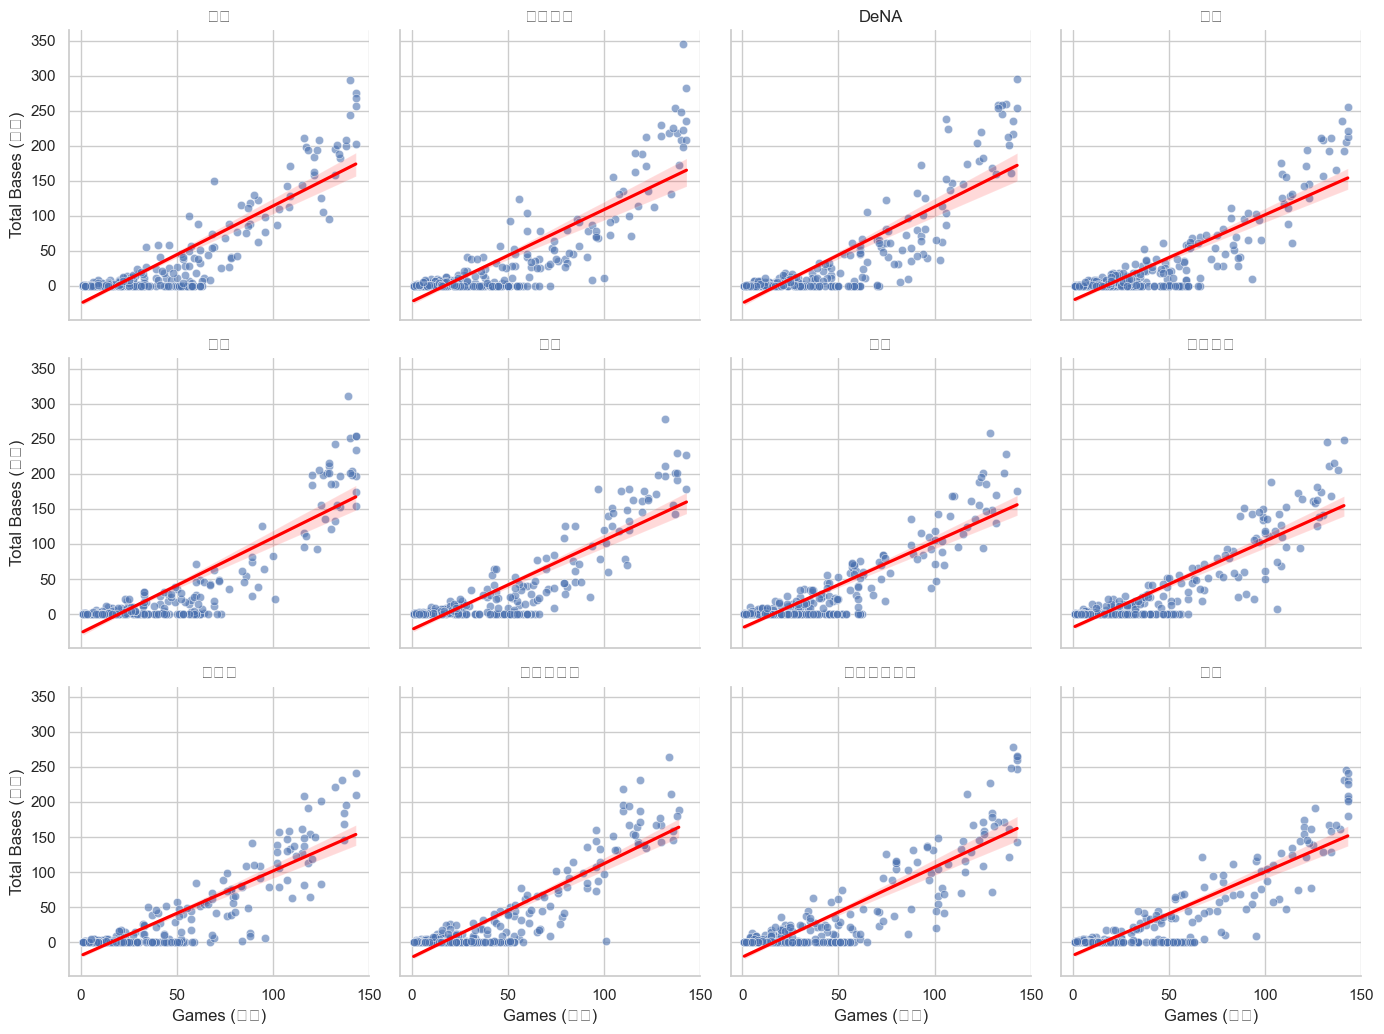

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data with Japanese Encoding
try:
    # We added encoding='shift_jis' here to fix the UnicodeDecodeError
    df = pd.read_csv('stats_bat.csv', encoding='shift_jis')
    print("Data loaded successfully!")
except UnicodeDecodeError:
    # If shift_jis fails, try cp932
    print("Shift_jis failed, trying cp932...")
    df = pd.read_csv('stats_bat.csv', encoding='cp932')
    print("Data loaded successfully with cp932!")
except FileNotFoundError:
    print("Error: 'stats_bat.csv' file not found.")
    exit()

# 2. Calculate Correlation
correlations = df.groupby('team_name')[['g', 'tb']].corr().iloc[0::2, -1].reset_index()
correlations = correlations.drop(columns=['level_1'])
correlations.columns = ['Team', 'Correlation']
correlations = correlations.sort_values('Correlation', ascending=False)

print("\n--- Correlation by Team ---")
print(correlations)

# 3. Visualization
sns.set(font="IPAexGothic")
sns.set_style("whitegrid")

g = sns.FacetGrid(df, col="team_name", col_wrap=4, height=3.5)
g.map(sns.scatterplot, "g", "tb", alpha=0.6)
g.map(sns.regplot, "g", "tb", scatter=False, color='red')

g.set_titles("{col_name}")
g.set_axis_labels("Games (試合)", "Total Bases (塁打)")

plt.tight_layout()
plt.show()